# Flight summary

Timing, certification, tracking and wind estimates of one or more flight logs written by the node
(`px4_rta_mm_gpr/flight_log` on the [flight_recorder](https://github.com/evannsmc/flight_recorder) library).
Works for SITL / hardware flights and for the numerical simulations of `04_numerical_sim.ipynb` (same file layout).

What a log contains: `ticks` (one row per 100 Hz control tick: state, command, the plan row in use and its certified
tube box), `wind` (wind-EKF updates), `gains` (LQR updates), every rollout plan (full tube, reference, feedforward and
the GP data it used), timing arrays, events (e.g. the LAND backup) and the node's configuration as metadata.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from px4_rta_mm_gpr import analysis as rta
rta.use_style()
pd.set_option('display.width', 200, 'display.max_columns', 30)
os.makedirs('figures', exist_ok=True)

In [2]:
# Flight logs to analyse. The example is the latest SITL flight committed with the repository; logs of your own
# runs are written by the node to <workspace>/src/data_analysis/log_files/px4_rta_mm_gpr/<name>.h5
EXAMPLE = 'log_files/sitl/sitl_python_loop_2026-09-28.h5'
WORKSPACE_LOGS = os.path.expanduser('~/Projects/old_projects/OJCSYS27/src/data_analysis/log_files/px4_rta_mm_gpr')
LOGS = [EXAMPLE]
# LOGS = sorted(glob.glob(os.path.join(WORKSPACE_LOGS, '*.h5')))[-5:]   # e.g. your five most recent flights
LOGS

['log_files/sitl/sitl_python_loop_2026-09-28.h5']

## Overview of all selected flights

In [3]:
pd.concat([rta.summary(rta.load(p)) for p in LOGS], ignore_index=True).T

,0
flight,sitl_python_loop_2026-09-28.h5
platform,sim
duration_s,19.989971
ticks,2000
control_rate_hz,100.000145
period_p99_ms,10.06773
ctrl_us_median,155.382499
uncertified_pct,0.0
rmse_y,0.022036
rmse_altitude,0.028784


## Configuration of the first flight (metadata)

In [4]:
log = rta.load(LOGS[0])
pd.Series({k: v for k, v in log.metadata.items() if not isinstance(v, np.ndarray)})

T_lookahead                                  0.8
backup                                      land
backup_grace                                0.02
begin_actuator_control                      15.0
collection_threshold                        0.25
control_period                              0.01
created                      2026-09-28T23:20:00
embedding                                     uw
entry_ramp                                     0
executor                                  events
format                           flight_recorder
format_version                                 1
gc_freeze                                      1
gc_no_full                                     1
git_commit                               e9c7e01
gp                                            tv
gp_epsilon                                  0.25
gp_feedforward                                 1
gp_learn                                       1
host                                     egmc-gt
land_time           

## Timing
The control period should sit at 10 ms; rollout compute is the time to compute one certified plan (early exit at the
certification point); plan age is how old the plan used by each control tick was.

,control period (ms),control compute (us),rollout compute (ms)
count,1999.000,2000.000,46.000
mean,10.000,174.758,5.367
std,0.029,81.337,0.824
min,9.820,64.841,3.358
50%,10.000,155.382,5.360
99%,10.068,448.701,6.769
max,10.232,1335.365,6.806


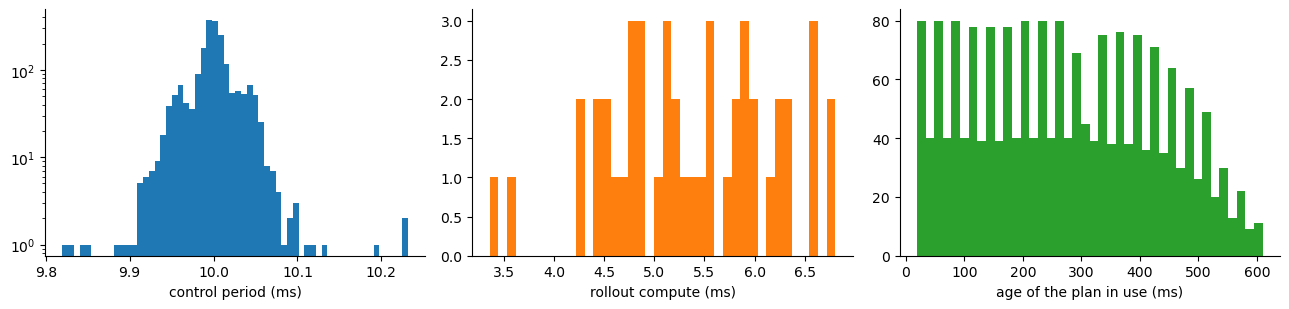

In [5]:
T = log.ticks
period_ms = 1e3 * np.diff(T['time'].to_numpy())
roll_ms = 1e3 * rta.rollout_times(log)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2))
axs[0].hist(period_ms, bins=60, color='tab:blue'); axs[0].set_xlabel('control period (ms)'); axs[0].set_yscale('log')
axs[1].hist(roll_ms, bins=40, color='tab:orange'); axs[1].set_xlabel('rollout compute (ms)')
axs[2].hist(1e3 * T['plan_age'], bins=40, color='tab:green'); axs[2].set_xlabel('age of the plan in use (ms)')
fig.tight_layout(); fig.savefig('figures/timing.pdf')
pd.DataFrame({'control period (ms)': pd.Series(period_ms).describe(percentiles=[.5, .99]),
              'control compute (us)': (1e6 * T['ctrl_comp_time']).describe(percentiles=[.5, .99]),
              'rollout compute (ms)': pd.Series(roll_ms).describe(percentiles=[.5, .99])}).round(3)

## Tracking
Deviation from the plan row in use (what the RTA feedback corrects), and the time series with the certified tube row.

RMSE lateral 0.022 m, altitude 0.029 m; ticks on an expired plan: 0.00 %


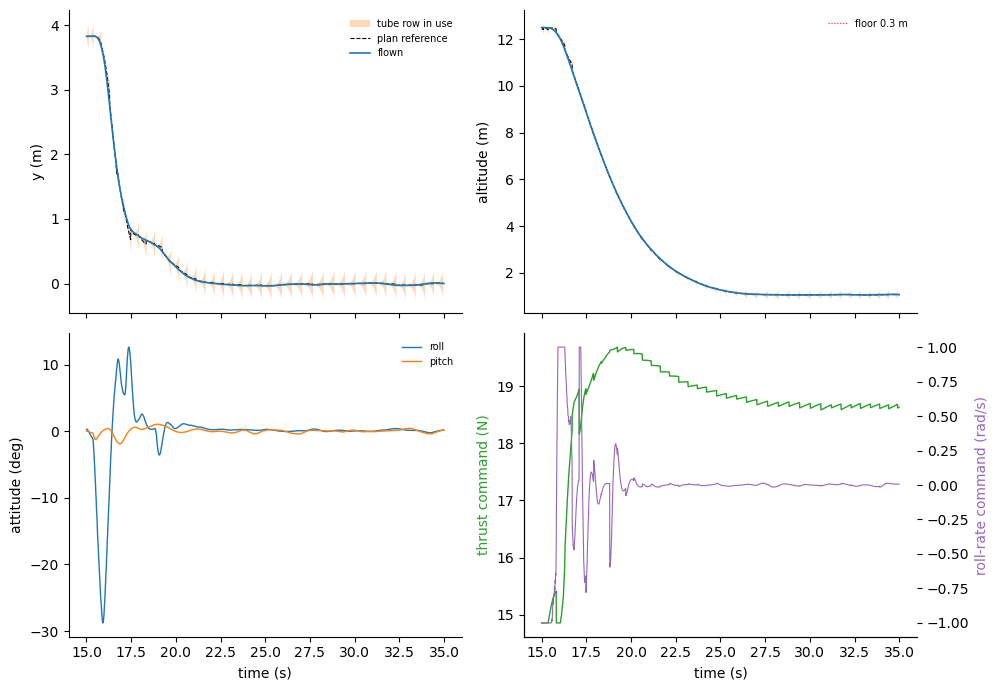

In [6]:
E = rta.tracking_errors(log)
print(f"RMSE lateral {np.sqrt(np.mean(E['e_y']**2)):.3f} m, altitude {np.sqrt(np.mean(E['e_altitude']**2)):.3f} m; "
      f"ticks on an expired plan: {100 * E['expired'].mean():.2f} %")
fig = rta.plot_timeseries(log); fig.savefig('figures/timeseries.pdf')

## Wind estimates and events

,time,kind,detail


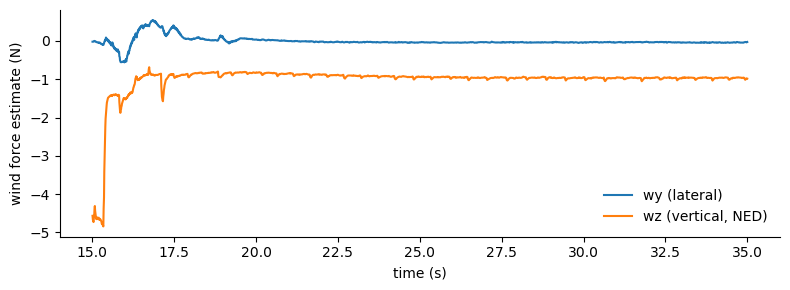

In [7]:
W = log.wind
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(W['time'], W['wy'], label='wy (lateral)'); ax.plot(W['time'], W['wz'], label='wz (vertical, NED)')
ax.set_xlabel('time (s)'); ax.set_ylabel('wind force estimate (N)'); ax.legend(frameon=False)
fig.tight_layout()
log.events